# Fitting 04 — Probability Calibration

Last step of the Fitting stage. The selected models rank borrowers well but their raw
scores are not honest probabilities (class weighting shifts them upward), and the
cost-sensitive thresholds of the Scoring stage need honest probabilities. The validation
split is divided once into a calibration-fit part (40%) and an evaluation part (60%);
three calibrators (Platt, Beta, isotonic) are fitted per model on the fit part, and the
one with the lowest calibration error (Brier reliability component) on the evaluation
part is kept. The fitted calibrators and the split indices are saved for the Scoring
stage, which reuses both unchanged.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from betacal import BetaCalibration

In [2]:
# Paths, seed and the models selected in Fitting 03. The 40/60 split favours the
# evaluation side because it must support both calibrator selection here and the
# threshold optimisation of Scoring 01.
SEED = 42
ARTIFACTS = Path("../artifacts")
CALIBRATORS_DIR = ARTIFACTS / "calibrators"
CALIBRATORS_DIR.mkdir(exist_ok=True)
VAL_FIT_FRACTION = 0.40
METHODS = ["platt", "beta", "isotonic"]
selected = json.loads((ARTIFACTS / "tuned_params.json").read_text())["selected"]
print("selected models:", selected)

selected models: {'logreg': 'logreg_C', 'rf': 'rf_C', 'xgb': 'xgb_C'}


In [3]:
# One-time stratified split of the validation rows into val-fit (calibrator fitting) and
# val-eval (calibrator selection + later threshold optimisation). The indices are saved so
# the Scoring notebooks use exactly the same val-eval rows - and the test split stays
# completely untouched until Scoring 02.
y_val = pd.read_parquet(ARTIFACTS / "val_configA.parquet")["target"].to_numpy()
fit_idx, eval_idx = train_test_split(np.arange(len(y_val)),
                                     train_size=VAL_FIT_FRACTION,
                                     stratify=y_val, random_state=SEED)
fit_idx.sort(); eval_idx.sort()
y_fit, y_eval = y_val[fit_idx], y_val[eval_idx]
print(f"val-fit : {len(fit_idx):,} rows ({y_fit.mean():.4%} defaults)")
print(f"val-eval: {len(eval_idx):,} rows ({y_eval.mean():.4%} defaults)")

val-fit : 11,951 rows (6.7024% defaults)
val-eval: 17,927 rows (6.6994% defaults)


In [4]:
# Raw (uncalibrated) validation scores of the three selected models, split into the fit
# and eval parts. The mean raw score is far above the 6.7% default rate - the visible
# symptom of the miscalibration that this notebook corrects.
raw_scores = {}
for family, key in selected.items():
    cfg = key.split("_")[1]
    model = joblib.load(ARTIFACTS / "models" / f"{key}.joblib")
    X_val = pd.read_parquet(ARTIFACTS / f"val_config{cfg}.parquet").drop(columns="target")
    scores = model.predict_proba(X_val)[:, 1]
    raw_scores[key] = {"fit": scores[fit_idx], "eval": scores[eval_idx]}
    print(f"{key}: mean raw score {scores.mean():.4f}  (true default rate {y_val.mean():.4f})")

logreg_C: mean raw score 0.3483  (true default rate 0.0670)


rf_C: mean raw score 0.3138  (true default rate 0.0670)
xgb_C: mean raw score 0.3216  (true default rate 0.0670)


In [5]:
# The three calibrators as a pair of explicit functions. Platt scaling fits a logistic
# regression on the raw score (a smooth two-parameter sigmoid), Beta calibration fits the
# more flexible three-parameter beta curve, and isotonic regression fits a step-wise
# monotone curve with no shape assumption at all.
def fit_calibrator(method, scores, y):
    if method == "platt":
        return LogisticRegression(solver="lbfgs").fit(scores.reshape(-1, 1), y)
    if method == "beta":
        return BetaCalibration().fit(scores, y)
    if method == "isotonic":
        return IsotonicRegression(out_of_bounds="clip").fit(scores, y)
    raise ValueError(method)

def apply_calibrator(method, calibrator, scores):
    if method == "platt":
        p = calibrator.predict_proba(scores.reshape(-1, 1))[:, 1]
    else:
        p = np.asarray(calibrator.predict(scores)).ravel()
    return np.clip(p, 0.0, 1.0)

In [6]:
# Brier score decomposition (CORP method): BS = reliability - resolution + uncertainty.
# The reliability term isolates pure calibration error (how far the stated probabilities
# are from the observed frequencies) from discrimination, so calibrators are selected on
# reliability alone - selecting on the full Brier score would mix the two qualities.
def brier_decomposition(y, probabilities):
    recalibrated = IsotonicRegression(out_of_bounds="clip").fit_transform(probabilities, y)
    brier = float(np.mean((probabilities - y) ** 2))
    brier_recalibrated = float(np.mean((recalibrated - y) ** 2))
    uncertainty = float(y.mean() * (1 - y.mean()))
    return {"brier": brier,
            "reliability": brier - brier_recalibrated,
            "resolution": uncertainty - brier_recalibrated,
            "uncertainty": uncertainty}

In [7]:
# Fit the three calibrators per model on val-fit, apply them on val-eval, and decompose
# the Brier score of every variant (uncalibrated + three calibrated). Calibration removes
# ~99% of the reliability error for every model family.
calibrators, eval_probabilities, records = {}, {}, []
for family, key in selected.items():
    calibrators[key] = {m: fit_calibrator(m, raw_scores[key]["fit"], y_fit)
                        for m in METHODS}
    eval_probabilities[key] = {"uncalibrated": raw_scores[key]["eval"]}
    for m in METHODS:
        eval_probabilities[key][m] = apply_calibrator(m, calibrators[key][m],
                                                      raw_scores[key]["eval"])
    for variant, p in eval_probabilities[key].items():
        records.append({"model": key, "variant": variant,
                        **brier_decomposition(y_eval, p)})
decomposition = pd.DataFrame(records)
decomposition.round(5)

,model,variant,brier,reliability,resolution,uncertainty
0,logreg_C,uncalibrated,0.14578,0.09629,0.01301,0.06251
1,logreg_C,platt,0.05001,0.00051,0.01301,0.06251
2,logreg_C,beta,0.04993,0.00044,0.01301,0.06251
3,logreg_C,isotonic,0.05015,0.00047,0.01283,0.06251
4,rf_C,uncalibrated,0.13452,0.08547,0.01346,0.06251
5,rf_C,platt,0.04962,0.00058,0.01346,0.06251
6,rf_C,beta,0.04942,0.00037,0.01346,0.06251
7,rf_C,isotonic,0.04974,0.00045,0.01321,0.06251
8,xgb_C,uncalibrated,0.14319,0.09424,0.01356,0.06251
9,xgb_C,platt,0.04985,0.00091,0.01356,0.06251


In [8]:
# Select the calibrator with the lowest reliability per model and report the improvement
# over the uncalibrated scores.
chosen = {}
for family, key in selected.items():
    sub = decomposition[decomposition.model == key].set_index("variant")
    best = sub.loc[METHODS, "reliability"].idxmin()
    chosen[key] = best
    print(f"{key}: {best:9s}  reliability "
          f"{sub.loc['uncalibrated', 'reliability']:.5f} (uncalibrated) -> "
          f"{sub.loc[best, 'reliability']:.5f}")

logreg_C: beta       reliability 0.09629 (uncalibrated) -> 0.00044
rf_C: beta       reliability 0.08547 (uncalibrated) -> 0.00037
xgb_C: isotonic   reliability 0.09424 (uncalibrated) -> 0.00033


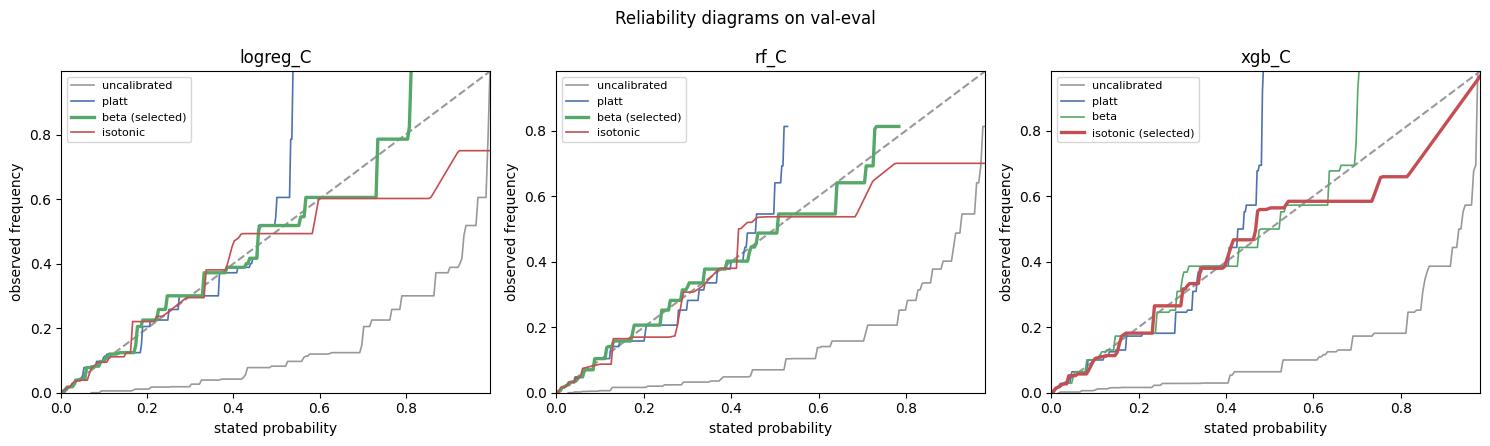

In [9]:
# Reliability diagrams on val-eval: stated probability (x) against observed frequency
# (y, isotonic-smoothed). A perfectly calibrated model follows the diagonal; the
# uncalibrated curves sit far above it, the selected calibrators hug it.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = {"uncalibrated": "#999999", "platt": "#4C72B0",
          "beta": "#55A868", "isotonic": "#C44E52"}
for ax, (family, key) in zip(axes, selected.items()):
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    for variant, p in eval_probabilities[key].items():
        smoother = IsotonicRegression(out_of_bounds="clip").fit(p, y_eval)
        xs = np.linspace(p.min(), p.max(), 200)
        width = 2.4 if variant == chosen[key] else 1.2
        label = variant + (" (selected)" if variant == chosen[key] else "")
        ax.plot(xs, smoother.predict(xs), color=colors[variant], lw=width, label=label)
    limit = max(eval_probabilities[key]["uncalibrated"].max(), 0.05)
    ax.set_xlim(0, limit); ax.set_ylim(0, limit)
    ax.set_title(key)
    ax.set_xlabel("stated probability")
    ax.set_ylabel("observed frequency")
    ax.legend(fontsize=8)
fig.suptitle("Reliability diagrams on val-eval")
plt.tight_layout()
plt.show()

In [10]:
# Persist the selected calibrator per model, the split indices, and the full Brier
# decomposition table so the selection is evidenced by an artifact, not just by notebook
# output. Scoring 01 reuses the val-eval rows for threshold optimisation; Scoring 02 and
# 03 apply the same calibrators to the test split.
for key, method in chosen.items():
    joblib.dump(calibrators[key][method], CALIBRATORS_DIR / f"{key}.joblib")
calibration = {
    "seed": SEED,
    "val_fit_idx": fit_idx.tolist(),
    "val_eval_idx": eval_idx.tolist(),
    "selected_calibrator": chosen,
    "decomposition": decomposition.round(6).to_dict(orient="records"),
}
(ARTIFACTS / "calibration.json").write_text(json.dumps(calibration))
print("saved: calibration.json +", sorted(p.name for p in CALIBRATORS_DIR.glob("*.joblib")))

saved: calibration.json + ['logreg_C.joblib', 'rf_C.joblib', 'xgb_C.joblib']
